In [1]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

from sklearn.model_selection import train_test_split

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
DATA_PATH = r"C:\\Users\\mayank\\OneDrive\\Desktop\\Project-FORESIGHT\\Data\\cleaned"
MODEL_PATH = r"C:\\Users\\mayank\\OneDrive\\Desktop\\Project-FORESIGHT\\models\\"

In [4]:
df = pd.read_csv(
    DATA_PATH + "\\" + "feature_engineered.csv"
)

print(df.shape)

df.head()

(515212, 46)


,date,store_id,sku_id,customer_id,quantity,unit_price_x,total_value,channel,discount_pct,sku_name,...,DayOfWeek,Weekend,Revenue,Lag_1,Lag_7,Rolling_Mean_7,Rolling_STD_7,Purchase_Count,Customer_Lifetime_Value,Sales_Frequency
0,2021-01-01,0.036398,0.416027,0.364447,-1.044236,-0.306602,-0.856064,0.289707,1.262380,-1.230732,...,0.386083,-0.72446,-0.856064,-1.754203,-1.754168,-3.470065,-2.896136,-0.575151,-0.575410,0.501105
1,2021-01-01,-0.448451,1.180861,0.001336,-1.044236,-0.519643,-0.942304,0.289707,1.262380,1.142714,...,0.386083,-0.72446,-0.942304,-1.044229,-1.754168,-3.470065,-2.896136,1.738972,1.738972,0.382756
2,2021-01-01,1.421682,0.050992,0.001336,0.375718,0.711878,1.285094,1.073148,-0.613906,-1.100934,...,0.386083,-0.72446,1.285094,-1.044229,-1.754168,-3.470065,-2.896136,1.738972,1.738972,0.423102
3,2021-01-01,0.729040,-0.661694,1.487375,1.085695,-0.044056,0.925495,-1.277176,1.262380,0.549352,...,0.386083,-0.72446,0.925495,0.375721,-1.754168,-3.470065,-2.896136,-0.575223,-0.575139,0.398895
4,2021-01-01,-1.348886,0.485557,-1.631068,-1.044236,0.054955,-0.709702,0.289707,-0.613906,-0.099637,...,0.386083,-0.72446,-0.709702,1.085696,-1.754168,-3.470065,-2.896136,-0.575006,-0.575173,0.495725


In [5]:
target = "quantity"

X = df.drop(columns=[target])

y = df[target]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

In [9]:
X_test = X_test.rename(columns={
    "Year": "year",
    "Month": "month",
    "Week": "weekofyear",
    "DayOfWeek": "dayofweek"
})

In [10]:
X_test = X_test.reindex(columns=rf.feature_names_in_, fill_value=0)

In [11]:
rf = joblib.load(

MODEL_PATH+"random_forest.pkl"

)

xgb = joblib.load(

MODEL_PATH+ "\\" + "xgboost.pkl"

)

print("Models Loaded Successfully")

Models Loaded Successfully


In [12]:
rf_pred = rf.predict(X_test)

xgb_pred = xgb.predict(X_test)

In [13]:
def evaluate_model(y_true, prediction):

    mae = mean_absolute_error(y_true, prediction)

    mse = mean_squared_error(y_true, prediction)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, prediction)

    mape = mean_absolute_percentage_error(
        y_true,
        prediction
    )

    return mae, mse, rmse, r2, mape

In [14]:
rf_mae, rf_mse, rf_rmse, rf_r2, rf_mape = evaluate_model(

    y_test,

    rf_pred

)

In [15]:
xgb_mae, xgb_mse, xgb_rmse, xgb_r2, xgb_mape = evaluate_model(

    y_test,

    xgb_pred

)

In [16]:
comparison = pd.DataFrame({

"Model":[

"Random Forest",

"XGBoost"

],

"MAE":[

rf_mae,

xgb_mae

],

"MSE":[

rf_mse,

xgb_mse

],

"RMSE":[

rf_rmse,

xgb_rmse

],

"MAPE":[

rf_mape,

xgb_mape

],

"R2":[

rf_r2,

xgb_r2

]

})

comparison

,Model,MAE,MSE,RMSE,MAPE,R2
0,Random Forest,0.000367,0.000063,0.007909,0.000266,0.999937
1,XGBoost,0.013859,0.000692,0.026304,0.019641,0.999304


In [17]:
best_model = comparison.sort_values(

by="R2",

ascending=False

)

best_model

,Model,MAE,MSE,RMSE,MAPE,R2
0,Random Forest,0.000367,0.000063,0.007909,0.000266,0.999937
1,XGBoost,0.013859,0.000692,0.026304,0.019641,0.999304


In [19]:
comparison.to_csv(

DATA_PATH+ "\\" +

"evaluation_metrics.csv",

index=False

)

print("Evaluation Metrics Saved")

Evaluation Metrics Saved


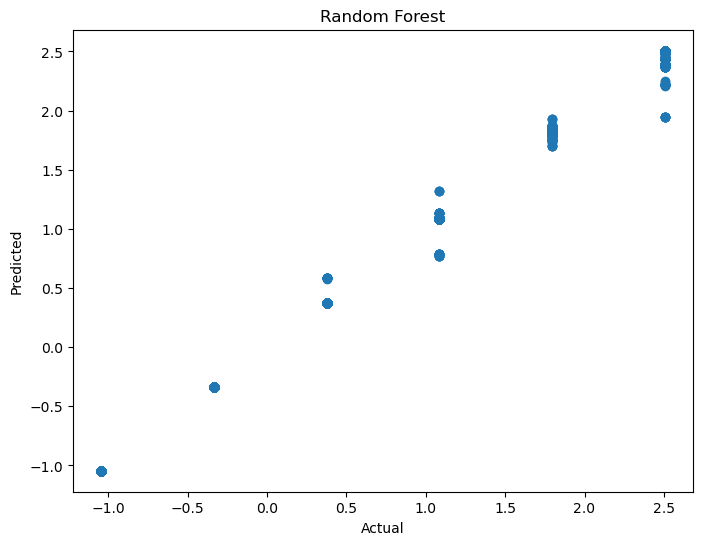

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(

y_test,

rf_pred

)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Random Forest")

plt.show()

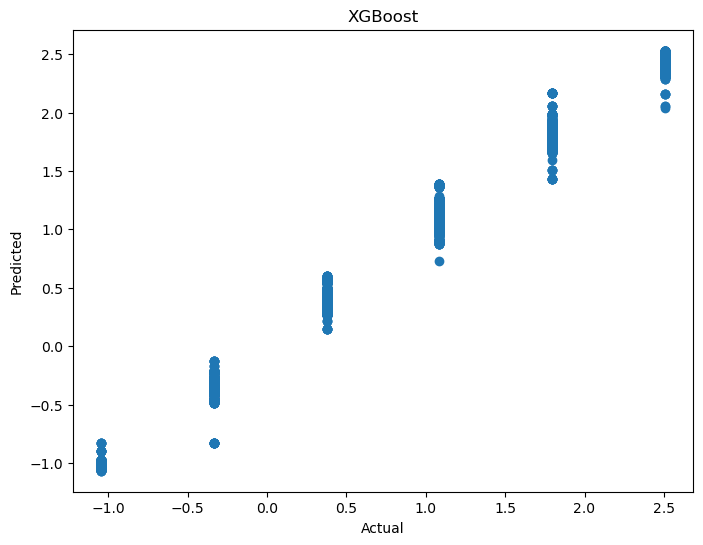

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(

y_test,

xgb_pred

)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("XGBoost")

plt.show()

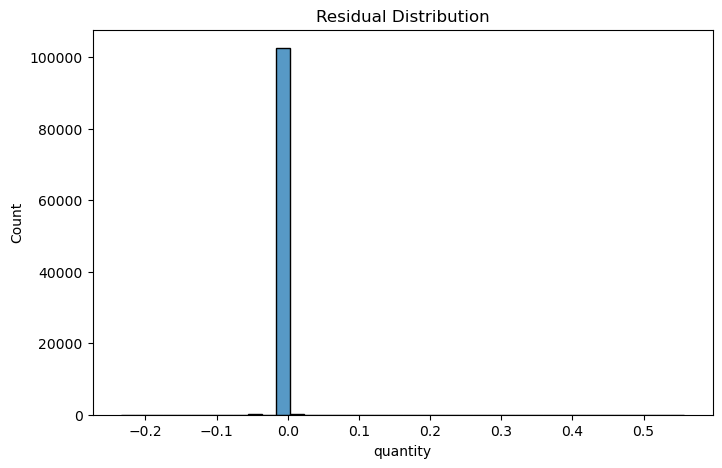

In [22]:
rf_residual = y_test-rf_pred

plt.figure(figsize=(8,5))

sns.histplot(

rf_residual,

bins=40

)

plt.title(

"Residual Distribution"

)

plt.show()

In [24]:
importance = pd.DataFrame({
    "Feature": rf.feature_names_in_,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

               Feature    Importance
3         unit_price_x  4.353624e-01
36             Revenue  2.944752e-01
4          total_value  2.658519e-01
40       Rolling_STD_7  3.128613e-03
10        unit_price_y  7.328869e-04
11          cost_price  2.753403e-04
43     Sales_Frequency  8.353677e-05
7             sku_name  2.356403e-05
1               sku_id  1.872851e-05
27   last_restock_date  1.407156e-05
8             category  1.188426e-05
6         discount_pct  8.944807e-06
24       stock_on_hand  6.494585e-06
9          subcategory  2.547668e-06
26        safety_stock  1.254824e-06
23  store_id_inventory  1.100662e-06
25       reorder_point  8.622416e-07
39      Rolling_Mean_7  2.962356e-07
37               Lag_1  1.545095e-07
33                 Day  4.375825e-08


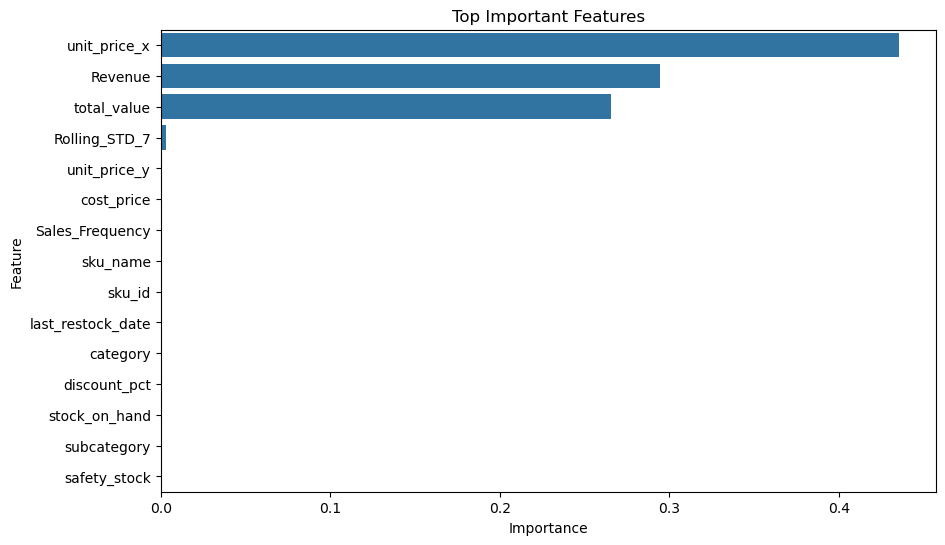

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(

data=importance.head(15),

x="Importance",

y="Feature"

)

plt.title(

"Top Important Features"

)

plt.show()

In [26]:
prediction = pd.DataFrame({

"Actual":y_test.values,

"RandomForest":rf_pred,

"XGBoost":xgb_pred

})

prediction.head(20)

,Actual,RandomForest,XGBoost
0,0.375718,0.375718,0.376004
1,2.505649,2.505649,2.490530
2,-0.334259,-0.334259,-0.329578
3,0.375718,0.375718,0.358462
4,2.505649,2.505649,2.460833
5,-1.044236,-1.044236,-1.038023
6,-0.334259,-0.334259,-0.321352
7,-1.044236,-1.044236,-1.037253
8,-1.044236,-1.044236,-1.037759
9,1.085695,1.087167,1.095959


In [28]:
prediction.to_csv(

DATA_PATH+ "\\" + "prediction_report.csv",

index=False

)

print("Prediction Report Saved")

Prediction Report Saved


In [29]:
summary = {

"Best Model":

best_model.iloc[0]["Model"],

"Best R2":

best_model.iloc[0]["R2"],

"Lowest RMSE":

best_model["RMSE"].min(),

"Lowest MAE":

best_model["MAE"].min()

}

summary

{'Best Model': 'Random Forest',
 'Best R2': 0.9999371195985186,
 'Lowest RMSE': 0.007908802323107832,
 'Lowest MAE': 0.0003670233216465146}

In [30]:
summary_df = pd.DataFrame(

summary,

index=[0]

)

summary_df.to_csv(

DATA_PATH+ "\\" +

"model_summary_final.csv",

index=False

)

print("Summary Saved")

Summary Saved


In [31]:
print("="*60)

print("MODEL PERFORMANCE")

print("="*60)

print(comparison)

MODEL PERFORMANCE
           Model       MAE       MSE      RMSE      MAPE        R2
0  Random Forest  0.000367  0.000063  0.007909  0.000266  0.999937
1        XGBoost  0.013859  0.000692  0.026304  0.019641  0.999304


In [32]:
print("="*60)

print("PHASE 7 COMPLETED")

print("="*60)

print("""
✔ Random Forest Evaluated
✔ XGBoost Evaluated
✔ MAE Calculated
✔ RMSE Calculated
✔ MAPE Calculated
✔ R² Calculated
✔ Prediction Report Saved
✔ Feature Importance Generated
✔ Final Report Generated
✔ AI Pipeline Completed Successfully
""")

PHASE 7 COMPLETED

✔ Random Forest Evaluated
✔ XGBoost Evaluated
✔ MAE Calculated
✔ RMSE Calculated
✔ MAPE Calculated
✔ R² Calculated
✔ Prediction Report Saved
✔ Feature Importance Generated
✔ Final Report Generated
✔ AI Pipeline Completed Successfully

